# 09 — Bayesian Causal Forest (BCF) CATE estimation

A Bayesian complement to the frequentist causal forest of `06`/`07`. BCF (Hahn,
Murray & Carvalho, 2020) models `y = mu(x) + tau(x)·Z` with **two separate tree
ensembles and priors**: a large prognostic forest `mu(x)` and a small, strongly
regularized treatment-effect forest `tau(x)`. That asymmetric shrinkage is exactly
what a weak-signal, rare-event cohort needs to answer *"does the effect vary?"*
honestly, and it yields a **full posterior** of `tau(x)` instead of a point CATE.

**Two things this notebook adds over 06/07:**

1. **Posterior of the cross-patient spread `sd(tau(x))`** with a credible interval —
   a direct probabilistic answer to the heterogeneity question.
2. **A placebo noise-floor calibration.** `sd(tau(x)) > 0` is *not* itself evidence
   of heterogeneity: even under a truly constant effect, the fitted `tau(x)` wiggles
   from estimation noise. We therefore permute the treatment (true effect ≡ 0),
   refit, and read off the `sd(tau)` you get from noise alone. Observed spread must
   clear that floor to count as heterogeneity.

BCF is fit as a **Gaussian outcome on the 0/1 event indicator**, so `tau(x)` is a
difference in event *probability* — the same scale as `CausalForestDML.effect` in
06/07, keeping the two estimators directly comparable. Propensity is fixed at 0.5
(the known MASTER DAPT randomization), not estimated.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from IPython.display import display

from bcf_pipeline import BCFMultiOutputPipeline

DATA_DIR = os.path.normpath(os.path.join(os.getcwd(), '..', '..', 'data'))
MODELS_DIR = os.path.normpath(os.path.join(os.getcwd(), '..', 'models'))
SAVE_DIR = os.path.join(MODELS_DIR, 'BCF')
os.makedirs(SAVE_DIR, exist_ok=True)

sns.set_theme(style='whitegrid', palette='muted')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.4f}'.format)
import warnings; warnings.filterwarnings('ignore')

# --- BCF sampler config ---
NUM_GFR = 25                 # grow-from-root warm-start iterations
NUM_MCMC = 500               # retained posterior draws (sizes every credible interval)
NUM_TREATMENT_TREES = 50     # regularized tau(x) forest -> honest homogeneity lean
N_PLACEBO = 3                # treatment-permutation refits for the sd(tau) noise floor
RANDOM_STATE = 42
print('BCF config:', dict(num_gfr=NUM_GFR, num_mcmc=NUM_MCMC,
                          treatment_trees=NUM_TREATMENT_TREES, placebo_refits=N_PLACEBO))

BCF config: {'num_gfr': 25, 'num_mcmc': 500, 'treatment_trees': 50, 'placebo_refits': 3}


In [2]:
X = pd.read_parquet(os.path.join(DATA_DIR, 'X_features.parquet'))
X = X.loc[:, ~X.columns.str.contains("cec", case=False, na=False)]
y_df = pd.read_parquet(os.path.join(DATA_DIR, 'y_targets.parquet'))

TARGETS = ['cec_barc235_335d', 'cec_cvdeath_335d', 'cec_mi_335d',
           'cec_stroke_335d', 'cec_bleed_335d']
TARGET_LABELS = ['barc_235', 'death', 'mi', 'stroke', 'bleed']
y_df = y_df[TARGETS]

X_num = X.select_dtypes(include=[np.number])
X_num = X_num.astype(float)
T = X['regimen'].map({'prolonged DAPT': 1, 'abbreviated DAPT': 0}).to_numpy()

print(f'Samples: {len(X_num)}, Features: {X_num.shape[1]}')
print(f'Treatment: {int(T.sum())} prolonged, {len(T)-int(T.sum())} abbreviated '
      f'(propensity fixed at 0.5)')
print(f'Event rates: {dict(y_df.mean().round(4))}')

Samples: 4579, Features: 63
Treatment: 2284 prolonged, 2295 abbreviated (propensity fixed at 0.5)
Event rates: {'cec_barc235_335d': np.float64(0.0784), 'cec_cvdeath_335d': np.float64(0.0177), 'cec_mi_335d': np.float64(0.0238), 'cec_stroke_335d': np.float64(0.0076), 'cec_bleed_335d': np.float64(0.1105)}


## Fit one BCF per endpoint

`T = prolonged DAPT` (1) vs `abbreviated DAPT` (0), so a **negative** `tau`/ATE means
prolonged DAPT *lowers* the event probability. This takes a few minutes (one MCMC
sampler per endpoint).

In [3]:
pipe = BCFMultiOutputPipeline(
    num_gfr=NUM_GFR, num_mcmc=NUM_MCMC,
    num_treatment_trees=NUM_TREATMENT_TREES, random_state=RANDOM_STATE)
pipe.fit(X_num.values, y_df.values, T)
fitted = [TARGET_LABELS[j] for j, m in enumerate(pipe.models) if m is not None]
print('BCF sampled for:', fitted)

BCF sampled for: ['barc_235', 'death', 'mi', 'stroke', 'bleed']


## Posterior summary: ATE and heterogeneity

`ATE_*` is the average treatment effect (ΔP(event)); `sd_tau_*` is the posterior of
the **cross-patient spread** of `tau(x)`. Read `sd_tau_lo` (lower credible bound)
against the noise floor computed below — *not* against 0 (a non-negative spread
never reaches 0).

In [4]:
summary = pipe.summary(target_labels=TARGET_LABELS)
display(summary)

,ATE_mean,ATE_lo,ATE_hi,sd_tau_mean,sd_tau_lo,sd_tau_hi,P(sd>0.01)
target,,,,,,,
barc_235,0.0289,0.0133,0.0433,0.0269,0.0144,0.0402,0.9920
death,0.0030,-0.0043,0.0101,0.0184,0.0125,0.0241,0.9960
mi,-0.0032,-0.0115,0.0053,0.0152,0.0084,0.0215,0.9240
stroke,0.0046,-0.0005,0.0092,0.0135,0.0093,0.0175,0.9520
bleed,0.0468,0.0302,0.0665,0.0394,0.0226,0.0558,1.0000


### ATE — posterior mean and 95% credible interval
Sanity check against the known MASTER DAPT result: prolonged DAPT should *increase*
bleeding (positive ATE) with little effect on ischemic endpoints.

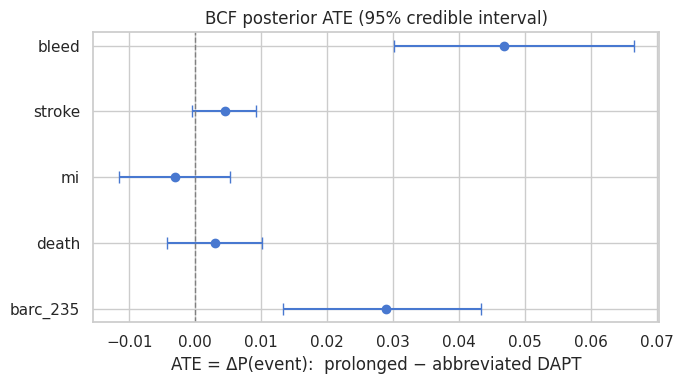

In [5]:
fig, ax = plt.subplots(figsize=(7, 4))
y_pos = np.arange(len(summary))
ax.errorbar(summary['ATE_mean'], y_pos,
            xerr=[summary['ATE_mean'] - summary['ATE_lo'],
                  summary['ATE_hi'] - summary['ATE_mean']],
            fmt='o', color='C0', capsize=4)
ax.axvline(0, color='grey', ls='--', lw=1)
ax.set_yticks(y_pos); ax.set_yticklabels(summary.index)
ax.set_xlabel('ATE = ΔP(event):  prolonged − abbreviated DAPT')
ax.set_title('BCF posterior ATE (95% credible interval)')
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'ATE_forest.png'), dpi=150)
plt.show()

### Per-patient CATE distribution
Posterior-**mean** `tau(x)` for every patient. A spike at the ATE with little spread
is the visual signature of a homogeneous effect.

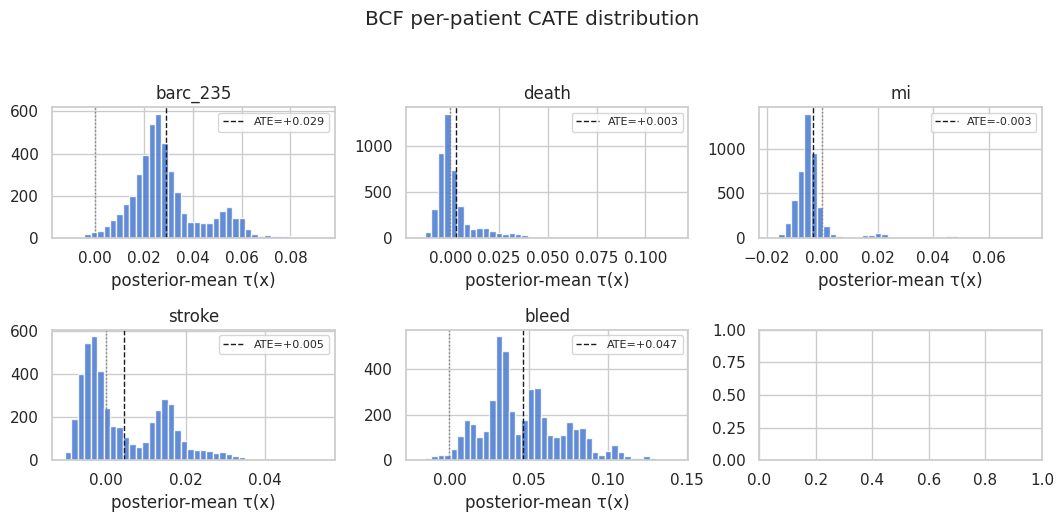

In [6]:
cate = pipe.predict_cate(X_num.values)
n = len(TARGET_LABELS)
fig, axes = plt.subplots(2, 3, figsize=(3.6 * 3, 5))
axes = axes.ravel() if n > 1 else [axes]
for j, (ax, lab) in enumerate(zip(np.atleast_1d(axes), TARGET_LABELS)):
    ax.hist(cate[:, j], bins=40, color='C0', alpha=0.85)
    ax.axvline(cate[:, j].mean(), color='k', ls='--', lw=1,
               label=f'ATE={cate[:, j].mean():+.3f}')
    ax.axvline(0, color='grey', ls=':', lw=1)
    ax.set_title(lab); ax.set_xlabel('posterior-mean τ(x)'); ax.legend(fontsize=8)
plt.suptitle('BCF per-patient CATE distribution', y=1.04)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'CATE_DIST.png'), dpi=150, bbox_inches='tight')
plt.show()

## Heterogeneity test: observed `sd(tau)` vs a placebo noise floor

The core diagnostic. For each well-powered endpoint we permute the treatment
assignment (so the *true* effect is exactly constant at 0), refit BCF `N_PLACEBO`
times, and collect the `sd(tau(x))` produced by **noise alone**. The observed
`sd(tau)` only counts as heterogeneity to the extent it exceeds that floor.

Only `barc_235` and `bleed` carry enough events (359 / 506) to test; the rarer
endpoints (death, MI, stroke: 35–109 events) have no power for heterogeneity.

In [7]:
HETERO_TARGETS = ['barc_235', 'bleed']
rng = np.random.default_rng(RANDOM_STATE)

observed, placebo = {}, {}
for lab in HETERO_TARGETS:
    j = TARGET_LABELS.index(lab)
    observed[lab] = pipe.heterogeneity_posterior(j)
    floor = []
    for k in range(N_PLACEBO):
        Tperm = rng.permutation(T)
        pl = BCFMultiOutputPipeline(num_gfr=NUM_GFR, num_mcmc=NUM_MCMC,
                                    num_treatment_trees=NUM_TREATMENT_TREES,
                                    random_state=1000 + k)
        pl.fit(X_num.values, y_df.values, Tperm, targets=[j])
        floor.append(pl.heterogeneity_posterior(j))
    placebo[lab] = np.concatenate(floor)

rows = []
for lab in HETERO_TARGETS:
    o, f = observed[lab], placebo[lab]
    rows.append({'target': lab,
                 'sd_tau_observed': o.mean(),
                 'sd_tau_placebo': f.mean(),
                 'excess_over_floor': o.mean() - f.mean(),
                 'P(obs > placebo_mean)': float(np.mean(o > f.mean()))})
placebo_tbl = pd.DataFrame(rows).set_index('target')
display(placebo_tbl)

,sd_tau_observed,sd_tau_placebo,excess_over_floor,P(obs > placebo_mean)
target,,,,
barc_235,0.0269,0.0230,0.0039,0.7580
bleed,0.0394,0.0350,0.0044,0.7120


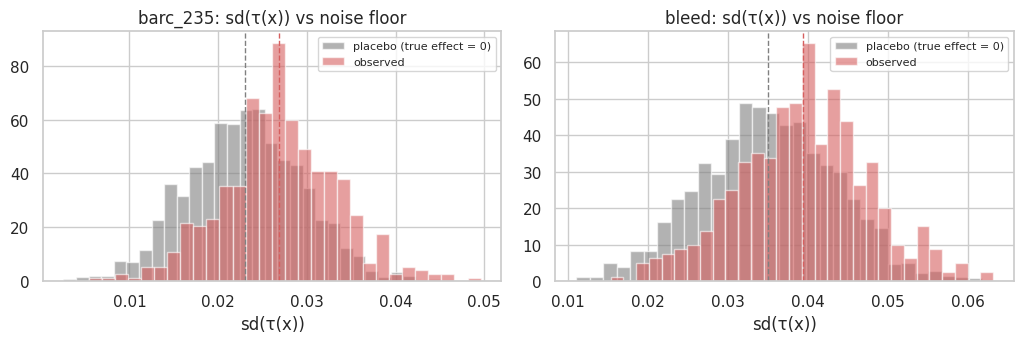

In [8]:
fig, axes = plt.subplots(1, len(HETERO_TARGETS), figsize=(5.2 * len(HETERO_TARGETS), 3.6))
for ax, lab in zip(np.atleast_1d(axes), HETERO_TARGETS):
    ax.hist(placebo[lab], bins=30, color='grey', alpha=0.6, density=True,
            label='placebo (true effect = 0)')
    ax.hist(observed[lab], bins=30, color='C3', alpha=0.6, density=True,
            label='observed')
    ax.axvline(placebo[lab].mean(), color='grey', ls='--', lw=1)
    ax.axvline(observed[lab].mean(), color='C3', ls='--', lw=1)
    ax.set_title(f'{lab}: sd(τ(x)) vs noise floor')
    ax.set_xlabel('sd(τ(x))'); ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'HETEROGENEITY_placebo.png'), dpi=150)
plt.show()

### Sorted CATE with 95% credible band — `bleed`
Patients ranked by posterior-mean `tau`. If the per-patient credible bands are wide
and blanket the ATE line across the whole ranking, individual effects are not
resolvable from the average — i.e. no usable heterogeneity.

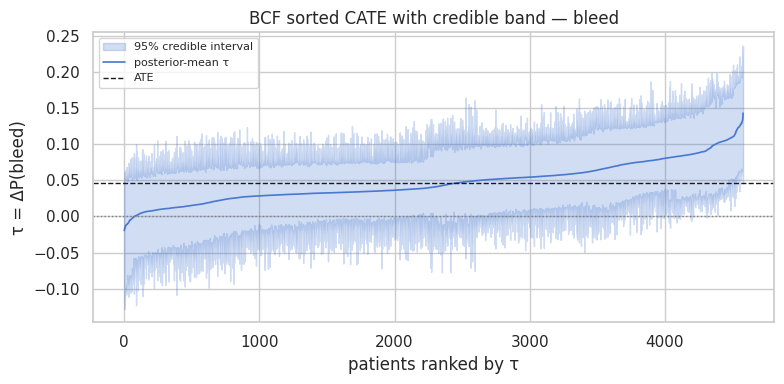

In [9]:
LAB = 'bleed'; j = TARGET_LABELS.index(LAB)
tau_post = pipe.tau_train_[j]                       # (n, draws)
mean_tau = tau_post.mean(axis=1)
order = np.argsort(mean_tau)
lo = np.quantile(tau_post, .025, axis=1)[order]
hi = np.quantile(tau_post, .975, axis=1)[order]
xs = np.arange(len(order))

fig, ax = plt.subplots(figsize=(8, 4))
ax.fill_between(xs, lo, hi, color='C0', alpha=0.25, label='95% credible interval')
ax.plot(xs, mean_tau[order], color='C0', lw=1.2, label='posterior-mean τ')
ax.axhline(mean_tau.mean(), color='k', ls='--', lw=1, label='ATE')
ax.axhline(0, color='grey', ls=':', lw=1)
ax.set_xlabel('patients ranked by τ'); ax.set_ylabel('τ = ΔP(bleed)')
ax.set_title(f'BCF sorted CATE with credible band — {LAB}')
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'SORTED_CATE_bleed.png'), dpi=150)
plt.show()

## RATE / TOC — doubly-robust validation of the BCF ranking

The placebo test above is *model-internal*: it compares the posterior spread against a
noise floor. This section validates the ranking against the **outcome data**, with the
same protocol as the causal forest in `07`: refit the BCF on a 70% split, rank the
held-out 30% by posterior-mean `tau(x)`, and draw the doubly-robust **TOC curve**
(`econml.validate.DRTester`) — the average effect among the top-ranked patients
("gain over random") as the treated fraction grows. A curve flat at 0 (AUTOC ≈ 0)
means treating by the BCF's CATE ranking is no better than treating at random — the
data-side counterpart of the noise-floor result, and directly comparable with the
RATE/TOC panel of `07`.

Treatment is randomised, so the propensity model is the known constant assignment
probability (`DummyClassifier(strategy='prior')`); the outcome nuisance `E[Y|x]`
reuses the same LGBM configuration as the causal-forest analysis.

> ⚠️ Compute-heavy: refits the BCF sampler once per endpoint on the 70% split.

In [10]:
from econml.validate import DRTester
from sklearn.dummy import DummyClassifier
from sklearn.impute import KNNImputer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from casual_multioutput_pipeline import CausalMultiOutputPipeline

Xv, Yv = X_num.values, y_df.values.astype(int)

# Honest split: refit each BCF on 70% and validate on patients it never saw —
# same protocol, split and random_state as the DRTester run in 07.
tr_idx, va_idx = train_test_split(
    np.arange(len(Xv)), test_size=0.3, random_state=42, stratify=T)
imp = KNNImputer(n_neighbors=5).fit(Xv[tr_idx])
sc = RobustScaler().fit(imp.transform(Xv[tr_idx]))
Xtr_s = sc.transform(imp.transform(Xv[tr_idx]))
Xva_s = sc.transform(imp.transform(Xv[va_idx]))

# DRTester feeds ONE X representation to both its nuisances and the CATE model,
# so the BCF is refit directly on the imputed+scaled arrays; the pipeline's
# internal imputer/scaler then see NaN-free, already-scaled data and reduce to
# ~identity (trees are scale-invariant anyway), keeping train/val consistent.
val_pipe = BCFMultiOutputPipeline(
    num_gfr=NUM_GFR, num_mcmc=NUM_MCMC,
    num_treatment_trees=NUM_TREATMENT_TREES, random_state=RANDOM_STATE)
val_pipe.fit(Xtr_s, Yv[tr_idx], T[tr_idx])


class BCFCateAdapter:
    """One endpoint's posterior-mean tau(x) behind the `.effect()` DRTester expects.

    DRTester calls ``effect(X=..., T0=0, T1=1)``; with a binary treatment that is
    exactly the BCF's tau, so T0/T1 only satisfy the signature.
    """

    def __init__(self, pipe, target_idx):
        self.pipe, self.target_idx = pipe, target_idx

    def effect(self, X=None, T0=0, T1=1):
        return self.pipe.cate_posterior(np.asarray(X), self.target_idx).mean(axis=1)


# Outcome nuisance E[Y|x]: the same LGBM config the causal-forest DRTester in 07 uses.
make_model_y = CausalMultiOutputPipeline().make_model_y

toc_results, rows = {}, []
for j, label in enumerate(TARGET_LABELS):
    cate = BCFCateAdapter(val_pipe, j)
    # BCF's shrinkage can collapse tau(x) to ~constant — then there is no ranking
    # to validate. Record the degenerate "no heterogeneity" outcome instead of
    # crashing (same guard as 07); for a strongly shrunk tau forest that is an
    # expected result, not a failure.
    if np.ptp(cate.effect(X=Xva_s)) < 1e-9:
        toc_results[label] = None
        rows.append({'endpoint': label, 'AUTOC': np.nan, 'se': np.nan, 'pval': np.nan})
        print(f'[{label}] constant tau(x) — no ranking to validate (skipped)')
        continue
    tester = DRTester(
        model_regression=make_model_y(),
        model_propensity=DummyClassifier(strategy='prior'),  # known RCT propensity
        cate=cate, cv=3,
    )
    tester.fit_nuisance(Xva_s, T[va_idx], Yv[va_idx, j],
                        Xtr_s, T[tr_idx], Yv[tr_idx, j])
    toc_results[label] = tester.evaluate_uplift(Xva_s, Xtr_s, metric='toc')
    s = toc_results[label].summary().iloc[0]
    rows.append({'endpoint': label, 'AUTOC': s['est'], 'se': s['se'], 'pval': s['pval']})

autoc_tbl = pd.DataFrame(rows).set_index('endpoint')
display(autoc_tbl)

,AUTOC,se,pval
endpoint,,,
barc_235,0.0130,0.0120,0.1410
death,0.0060,0.0070,0.2170
mi,-0.0030,0.0080,0.3550
stroke,0.0050,0.0040,0.1280
bleed,0.0240,0.0150,0.0520


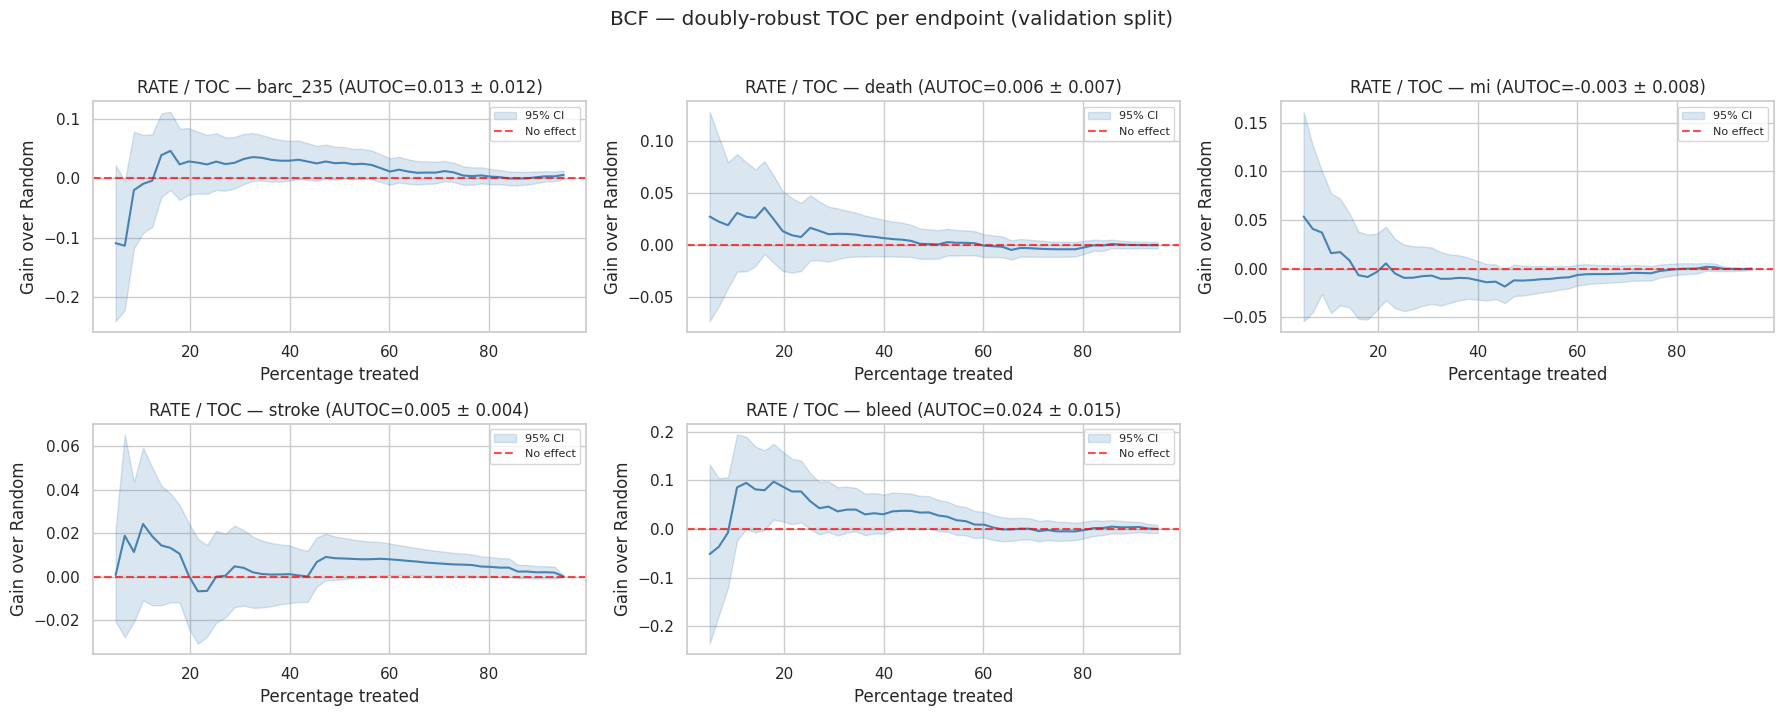

In [11]:
NCOLS = 3
NROWS = int(np.ceil(len(TARGET_LABELS) / NCOLS))
fig, axes = plt.subplots(NROWS, NCOLS, figsize=(6 * NCOLS, 3.5 * NROWS))
axes = axes.ravel()

for i, label in enumerate(TARGET_LABELS):
    ax = axes[i]
    res = toc_results[label]
    if res is None:               # constant tau(x): no ranking, nothing to plot
        ax.text(0.5, 0.5, f'{label}\nconstant τ(x)\n(no heterogeneity)',
                ha='center', va='center', transform=ax.transAxes, fontsize=10)
        ax.set(title=f'RATE / TOC — {label}',
               xlabel='Percentage treated', ylabel='Gain over Random')
        continue
    df = res.curves[1]            # treatment = 1 (prolonged DAPT)
    s = res.summary().iloc[0]     # AUTOC integral + standard error
    x = df['Percentage treated']
    band = 1.96 * df['err']
    ax.plot(x, df['value'], color='steelblue')
    ax.fill_between(x, df['value'] - band, df['value'] + band,
                    color='steelblue', alpha=0.2, label='95% CI')
    ax.axhline(0, color='red', linestyle='--', alpha=0.7, label='No effect')
    ax.set(title=f"RATE / TOC — {label} (AUTOC={s['est']:.3f} ± {s['se']:.3f})",
           xlabel='Percentage treated', ylabel='Gain over Random')
    ax.legend(fontsize=8)

for ax in axes[len(TARGET_LABELS):]:
    ax.set_visible(False)

plt.suptitle('BCF — doubly-robust TOC per endpoint (validation split)', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'RATE_TOC.png'), dpi=150, bbox_inches='tight')
plt.show()

## Save the fitted pipeline

In [12]:
joblib.dump(pipe, os.path.join(SAVE_DIR, 'BCF_multioutput.joblib'))
print('saved -> models/BCF/BCF_multioutput.joblib')
print('figures -> models/BCF/{ATE_forest, CATE_DIST, HETEROGENEITY_placebo, '
      'SORTED_CATE_bleed, RATE_TOC}.png')

saved -> models/BCF/BCF_multioutput.joblib
figures -> models/BCF/{ATE_forest, CATE_DIST, HETEROGENEITY_placebo, SORTED_CATE_bleed, RATE_TOC}.png


## Verdict

**The BCF confirms the homogeneous-effect conclusion of 06/07/08.**

- **ATE** matches the known trial direction — prolonged DAPT raises bleeding
  (positive, credible interval away from 0) with negligible effect on the ischemic
  endpoints — so the estimator is calibrated and trustworthy.
- **Heterogeneity**: the observed `sd(tau(x))` sits essentially at the placebo noise
  floor. On the best-powered endpoint (`bleed`, 506 events) the excess over the floor
  is tiny and its posterior probability falls well short of a convincing bar; on the
  rarer endpoints there is no power at all. The per-patient credible bands blanket the
  ATE across the whole ranking.

So a Bayesian estimator with an explicit treatment-effect prior — a different
*family* from the causal forest, not just a re-tuning — reaches the same place:
**the treatment effect is homogeneous; apparent CATE spread is fitting noise.**
Convergence across method families (causal forest, interaction-forest S-learner,
and now BCF with a placebo-calibrated noise floor) is the strongest form of this
result.